<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/loss_of_containment_consequence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loss-of-containment consequence analysis with NeqSim

This notebook carries a high-pressure sour-gas state from NeqSim thermodynamics
through transient source-term calculation, flammable and toxic dispersion
screening, jet-fire radiation, and vapor-cloud-explosion screening.

The models are screening tools. They do not replace validated project consequence
software, site geometry, ventilation analysis, CFD, explosion specialist review,
hazardous-area classification, or emergency-response studies.

## Learning objectives

You will learn to:

1. calculate a real-gas release state with an explicit composition and SRK model;
2. generate transient leak source terms for multiple hole sizes;
3. check choked-flow scaling and released-mass closure;
4. screen 0.5 LFL and 100 ppm H₂S downwind endpoints;
5. calculate jet-fire heat-flux and VCE overpressure distances;
6. combine the results into a consequence register for HAZOP follow-up.

## Model chain and equations

For a choked gas release, the reference orifice relation is:

$$
\dot{m} =
C_d A P_0
\sqrt{\frac{\gamma M}{R T_0}}
\left(\frac{2}{\gamma + 1}\right)^{
\frac{\gamma + 1}{2(\gamma - 1)}
}
$$

Jet-fire radiation is screened with a point-source model:

$$
q''(r) =
\frac{\eta \dot{m} \Delta H_c \tau(r)}
{4 \pi r^2}
$$

NeqSim supplies the flashed density, molar mass, heat-capacity ratio, phase
fraction, temperature, pressure, and time-dependent source term.

In [1]:
%pip install -q "neqsim==3.16.0" "pandas>=2.2" "matplotlib>=3.8" "scipy>=1.11"

Dependencies are installed and importable.


## Imports and runtime evidence

In [2]:
import importlib.metadata
import json
import platform
import sys

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))

,version
neqsim,3.16.0
python,3.12.13
java,17.0.19
numpy,2.5.1
pandas,3.0.5
matplotlib,3.11.1


## Define and flash the sour-gas inventory

In [3]:
SOUR_GAS_COMPONENTS = [
    ("nitrogen", 0.010),
    ("CO2", 0.015),
    ("methane", 0.890),
    ("ethane", 0.060),
    ("propane", 0.020),
    ("H2S", 0.005),
]

sour_gas = ns.thermo.system.SystemSrkEos(303.15, 100.0)
for component, mole_fraction in SOUR_GAS_COMPONENTS:
    sour_gas.addComponent(component, mole_fraction)
sour_gas.createDatabase(True)
sour_gas.setMixingRule(2)

flash = ns.thermodynamicoperations.ThermodynamicOperations(sour_gas)
flash.TPflash()
sour_gas.init(3)
sour_gas.initPhysicalProperties()

composition = pd.DataFrame(
    SOUR_GAS_COMPONENTS,
    columns=["component", "mole fraction"],
)
display(composition)
print(f"Composition sum: {composition['mole fraction'].sum():.12f}")

Composition sum: 1.000000000000


,component,mole fraction
0,nitrogen,0.010
1,CO2,0.015
2,methane,0.890
3,ethane,0.060
4,propane,0.020
5,H2S,0.005


In [4]:
gas_properties = pd.DataFrame(
    [
        ("Pressure", sour_gas.getPressure(), "bara"),
        ("Temperature", sour_gas.getTemperature() - 273.15, "°C"),
        ("Density", sour_gas.getDensity("kg/m3"), "kg/m³"),
        ("Molar mass", sour_gas.getMolarMass() * 1000.0, "kg/kmol"),
        ("Compressibility factor", sour_gas.getZ(), "-"),
        ("Heat-capacity ratio", sour_gas.getGamma(), "-"),
        ("Speed of sound", sour_gas.getSoundSpeed(), "m/s"),
    ],
    columns=["property", "value", "unit"],
)
gas_properties["value"] = gas_properties["value"].astype(float).round(4)
display(gas_properties)

,property,value,unit
0,Pressure,100.0000,bara
1,Temperature,30.0000,°C
2,Density,85.9855,kg/m³
3,Molar mass,18.0751,kg/kmol
4,Compressibility factor,0.8377,-
5,Heat-capacity ratio,1.7100,-
6,Speed of sound,422.7674,m/s


## Native transient source terms

The example assumes a 30 m³ isolated gas inventory, horizontal release,
discharge coefficient $C_d=0.82$, and atmospheric backpressure. Hole diameters
are scenario inputs, not predicted failure frequencies.

In [5]:
LeakModel = jpype.JClass(
    "neqsim.process.safety.release.LeakModel"
)
ReleaseOrientation = jpype.JClass(
    "neqsim.process.safety.release.ReleaseOrientation"
)

vessel_volume_m3 = 30.0
hole_diameters_mm = [5.0, 10.0, 25.0]
source_terms = {}
leak_models = {}

for diameter_mm in hole_diameters_mm:
    scenario_name = f"{diameter_mm:.0f} mm HP sour-gas leak"
    leak_model = (
        LeakModel.builder()
        .scenarioName(scenario_name)
        .fluid(sour_gas)
        .holeDiameter(diameter_mm, "mm")
        .backPressure(1.01325, "bar")
        .dischargeCoefficient(0.82)
        .orientation(ReleaseOrientation.HORIZONTAL)
        .vesselVolume(vessel_volume_m3)
        .build()
    )
    source_term = leak_model.calculateSourceTerm(600.0, 2.0)
    leak_models[diameter_mm] = leak_model
    source_terms[diameter_mm] = source_term
    print(source_term)

SourceTermResult[5 mm HP sour-gas leak, d=5.0mm, Horizontal release, peak=0.316 kg/s, total=48.9 kg, t_empty=309.9 s]
SourceTermResult[10 mm HP sour-gas leak, d=10.0mm, Horizontal release, peak=1.263 kg/s, total=97.4 kg, t_empty=154.2 s]
SourceTermResult[25 mm HP sour-gas leak, d=25.0mm, Horizontal release, peak=7.894 kg/s, total=240.6 kg, t_empty=61.0 s]


In [6]:
initial_inventory_kg = (
    sour_gas.getDensity("kg/m3") * vessel_volume_m3
)
source_summary_rows = []
for diameter_mm, source_term in source_terms.items():
    source_summary_rows.append(
        {
            "hole diameter [mm]": diameter_mm,
            "peak release [kg/s]": (
                source_term.getPeakMassFlowRate()
            ),
            "total released [kg]": (
                source_term.getTotalMassReleased()
            ),
            "reported emptying time [s]": (
                source_term.getTimeToEmpty()
            ),
            "inventory released [%]": (
                100.0
                * source_term.getTotalMassReleased()
                / initial_inventory_kg
            ),
        }
    )
source_summary = pd.DataFrame(source_summary_rows).round(3)
display(source_summary)
print(f"Initial flashed inventory: {initial_inventory_kg:.2f} kg")

Initial flashed inventory: 2579.56 kg


,hole diameter [mm],peak release [kg/s],total released [kg],reported emptying time [s],inventory released [%]
0,5.0,0.316,48.926,309.897,1.897
1,10.0,1.263,97.389,154.216,3.775
2,25.0,7.894,240.601,60.959,9.327


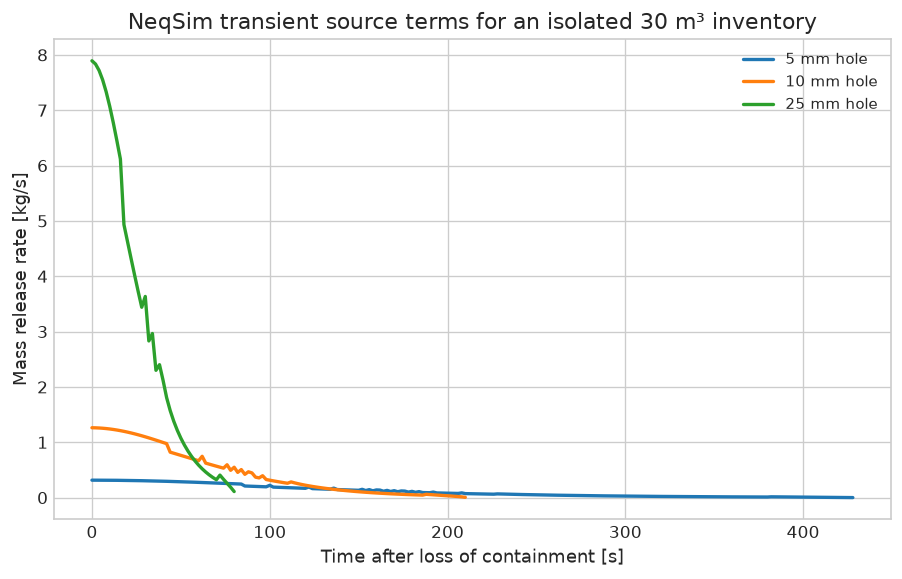

In [7]:
def active_source_arrays(source_term):
    time_values = np.asarray(source_term.getTime(), dtype=float)
    mass_rates = np.asarray(
        source_term.getMassFlowRate(),
        dtype=float,
    )
    positive_indices = np.flatnonzero(mass_rates > 0.0)
    if len(positive_indices) == 0:
        return time_values[:1], mass_rates[:1]
    last_index = positive_indices[-1] + 1
    return time_values[:last_index], mass_rates[:last_index]


fig, ax = plt.subplots(figsize=(9, 5.2))
for diameter_mm, source_term in source_terms.items():
    time_values, mass_rates = active_source_arrays(source_term)
    ax.plot(
        time_values,
        mass_rates,
        linewidth=2,
        label=f"{diameter_mm:.0f} mm hole",
    )
ax.set(
    xlabel="Time after loss of containment [s]",
    ylabel="Mass release rate [kg/s]",
    title="NeqSim transient source terms for an isolated 30 m³ inventory",
)
ax.legend()
plt.show()

## Analytical choked-flow check

In [8]:
gamma = sour_gas.getGamma()
molar_mass_kg_kmol = sour_gas.getMolarMass() * 1000.0
upstream_pressure_pa = sour_gas.getPressure() * 1.0e5
upstream_temperature_k = sour_gas.getTemperature()
discharge_coefficient = 0.82
universal_gas_constant = 8314.462618


def analytical_choked_rate(diameter_mm):
    diameter_m = diameter_mm / 1000.0
    area_m2 = np.pi * diameter_m**2 / 4.0
    flow_factor = (
        2.0 / (gamma + 1.0)
    ) ** (
        (gamma + 1.0)
        / (2.0 * (gamma - 1.0))
    )
    return (
        discharge_coefficient
        * area_m2
        * upstream_pressure_pa
        * np.sqrt(
            gamma
            * molar_mass_kg_kmol
            / universal_gas_constant
            / upstream_temperature_k
        )
        * flow_factor
    )


comparison_rows = []
for diameter_mm in hole_diameters_mm:
    native_rate = source_terms[
        diameter_mm
    ].getPeakMassFlowRate()
    analytical_rate = analytical_choked_rate(diameter_mm)
    comparison_rows.append(
        {
            "diameter [mm]": diameter_mm,
            "NeqSim [kg/s]": native_rate,
            "analytical [kg/s]": analytical_rate,
            "relative difference [%]": (
                100.0
                * (native_rate - analytical_rate)
                / analytical_rate
            ),
        }
    )
choked_check = pd.DataFrame(comparison_rows).round(5)
display(choked_check)

,diameter [mm],NeqSim [kg/s],analytical [kg/s],relative difference [%]
0,5.0,0.31576,0.31575,0.00278
1,10.0,1.26302,1.26299,0.00278
2,25.0,7.89389,7.89367,0.00278


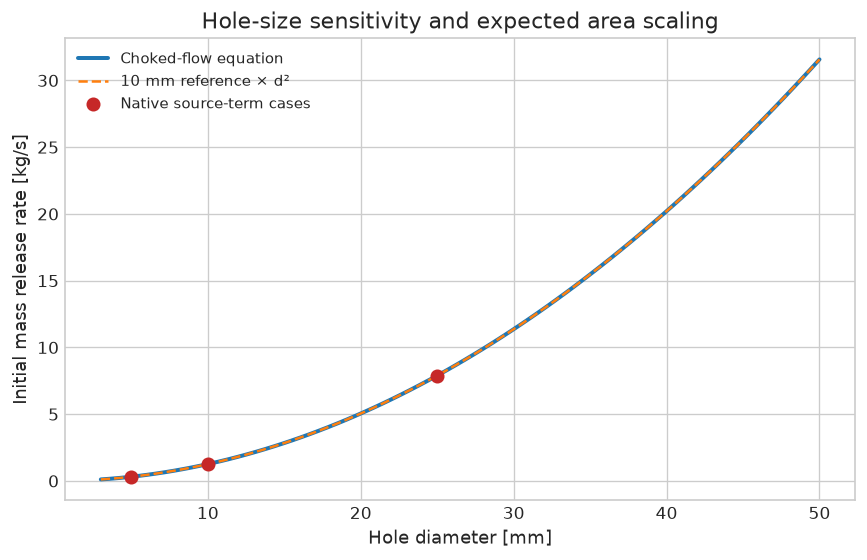

In [9]:
diameter_grid_mm = np.linspace(3.0, 50.0, 80)
analytical_rates = np.array(
    [
        analytical_choked_rate(diameter)
        for diameter in diameter_grid_mm
    ]
)
reference_rate = analytical_choked_rate(10.0)
area_scaling = reference_rate * (diameter_grid_mm / 10.0) ** 2

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(
    diameter_grid_mm,
    analytical_rates,
    linewidth=2.4,
    label="Choked-flow equation",
)
ax.plot(
    diameter_grid_mm,
    area_scaling,
    linestyle="--",
    label="10 mm reference × d²",
)
ax.scatter(
    source_summary["hole diameter [mm]"],
    source_summary["peak release [kg/s]"],
    s=55,
    color="#C62828",
    label="Native source-term cases",
    zorder=3,
)
ax.set(
    xlabel="Hole diameter [mm]",
    ylabel="Initial mass release rate [kg/s]",
    title="Hole-size sensitivity and expected area scaling",
)
ax.legend()
plt.show()

## Flammable and toxic dispersion screening

The native analyzer selects a passive Gaussian plume for this buoyant gas. The
screening endpoints are 0.5 LFL and 100 ppm H₂S. The wind/stability combinations
are scenario assumptions; real studies require a site metocean distribution,
geometry, release direction, ventilation, congestion, and model validation.

In [10]:
BoundaryConditions = jpype.JClass(
    "neqsim.process.safety.BoundaryConditions"
)
GasDispersionAnalyzer = jpype.JClass(
    "neqsim.process.safety.dispersion.GasDispersionAnalyzer"
)

wind_speeds_m_s = [2.0, 5.0, 10.0]
dispersion_rows = []
dispersion_results = {}

for diameter_mm, source_term in source_terms.items():
    for wind_speed in wind_speeds_m_s:
        boundary = (
            BoundaryConditions.builder()
            .ambientTemperature(10.0, "C")
            .windSpeed(wind_speed)
            .relativeHumidity(0.80)
            .pasquillStabilityClass("D")
            .isOffshore(True)
            .build()
        )
        result = (
            GasDispersionAnalyzer.builder()
            .scenarioName(
                f"{diameter_mm:.0f} mm, {wind_speed:.0f} m/s"
            )
            .fluid(sour_gas)
            .sourceTerm(source_term)
            .boundaryConditions(boundary)
            .releaseHeight(0.5)
            .flammableEndpointFraction(0.5)
            .toxicEndpoint("H2S", 100.0)
            .build()
            .analyze()
        )
        dispersion_results[(diameter_mm, wind_speed)] = result
        dispersion_rows.append(
            {
                "hole [mm]": diameter_mm,
                "wind [m/s]": wind_speed,
                "model": str(result.getSelectedModel()),
                "0.5 LFL distance [m]": (
                    result.getDistanceToFlammableEndpointM()
                ),
                "100 ppm H2S distance [m]": (
                    result.getToxicDistanceM()
                ),
                "flammable cloud [m³]": (
                    result.getFlammableCloudVolumeM3()
                ),
            }
        )

dispersion_df = pd.DataFrame(dispersion_rows).round(2)
display(dispersion_df)

,hole [mm],wind [m/s],model,0.5 LFL distance [m],100 ppm H2S distance [m],flammable cloud [m³]
0,5.0,2.0,GAUSSIAN_PLUME,24.59,25.30,10.65
1,5.0,5.0,GAUSSIAN_PLUME,14.75,15.18,0.55
2,5.0,10.0,GAUSSIAN_PLUME,9.04,9.58,0.00
3,10.0,2.0,GAUSSIAN_PLUME,50.68,52.53,133.20
4,10.0,5.0,GAUSSIAN_PLUME,31.40,32.79,27.27
5,10.0,10.0,GAUSSIAN_PLUME,21.60,22.55,6.39
6,25.0,2.0,GAUSSIAN_PLUME,131.25,136.07,2369.78
7,25.0,5.0,GAUSSIAN_PLUME,81.34,84.61,573.65
8,25.0,10.0,GAUSSIAN_PLUME,56.86,58.94,191.39


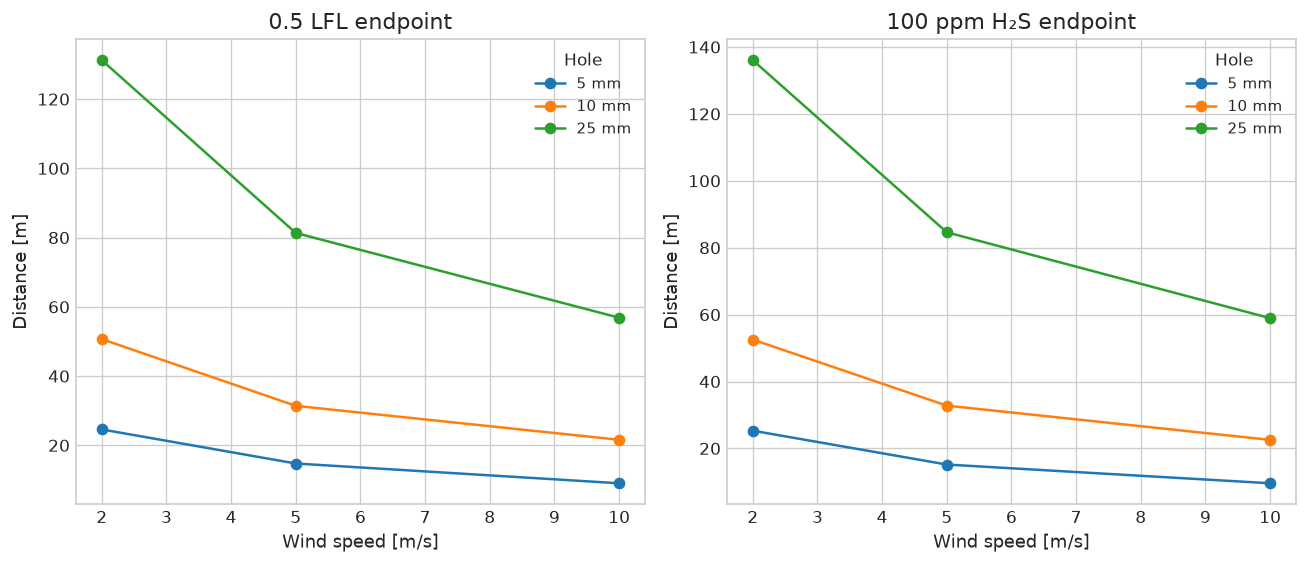

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True)
for diameter_mm, group in dispersion_df.groupby("hole [mm]"):
    axes[0].plot(
        group["wind [m/s]"],
        group["0.5 LFL distance [m]"],
        marker="o",
        label=f"{diameter_mm:.0f} mm",
    )
    axes[1].plot(
        group["wind [m/s]"],
        group["100 ppm H2S distance [m]"],
        marker="o",
        label=f"{diameter_mm:.0f} mm",
    )
axes[0].set(
    xlabel="Wind speed [m/s]",
    ylabel="Distance [m]",
    title="0.5 LFL endpoint",
)
axes[1].set(
    xlabel="Wind speed [m/s]",
    ylabel="Distance [m]",
    title="100 ppm H₂S endpoint",
)
axes[0].legend(title="Hole")
axes[1].legend(title="Hole")
plt.tight_layout()
plt.show()

## Jet-fire radiation screening

In [12]:
JetFireModel = jpype.JClass(
    "neqsim.process.safety.fire.JetFireModel"
)
heat_of_combustion_j_kg = 50.0e6
radiative_fraction = 0.20
heat_flux_targets_kw_m2 = [4.0, 12.5, 37.5]
jet_fire_rows = []
jet_fire_models = {}

for diameter_mm, source_term in source_terms.items():
    model = JetFireModel(
        source_term.getPeakMassFlowRate(),
        heat_of_combustion_j_kg,
        radiative_fraction,
    )
    model.setHumidity(0.80)
    jet_fire_models[diameter_mm] = model
    for target_kw_m2 in heat_flux_targets_kw_m2:
        jet_fire_rows.append(
            {
                "hole [mm]": diameter_mm,
                "target heat flux [kW/m²]": target_kw_m2,
                "distance [m]": (
                    model.distanceToFlux(target_kw_m2 * 1000.0)
                ),
            }
        )

jet_fire_df = pd.DataFrame(jet_fire_rows).round(2)
display(jet_fire_df)

,hole [mm],target heat flux [kW/m²],distance [m]
0,5.0,4.0,6.12
1,5.0,12.5,3.59
2,5.0,37.5,2.14
3,10.0,4.0,11.64
4,10.0,12.5,6.87
5,10.0,37.5,4.11
6,25.0,4.0,26.87
7,25.0,12.5,16.00
8,25.0,37.5,9.65


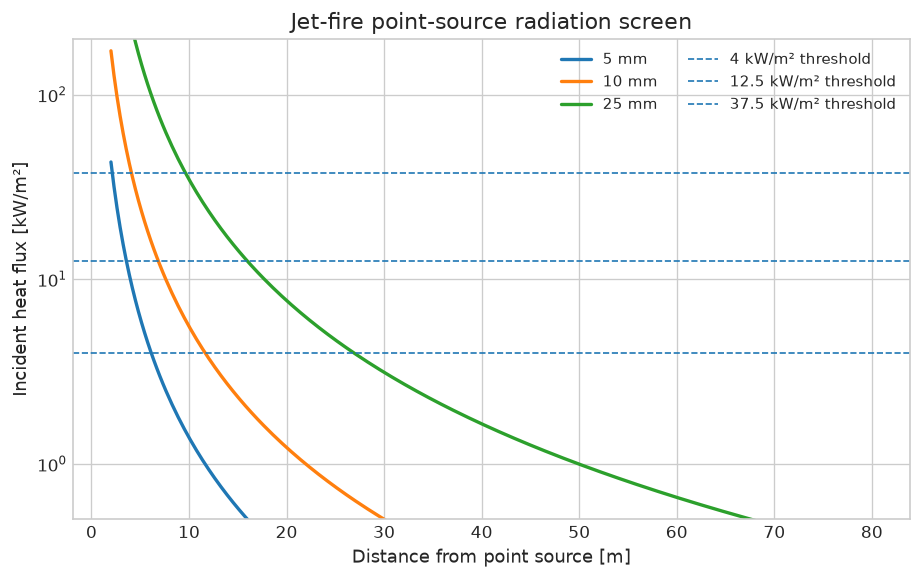

In [13]:
distance_grid_m = np.linspace(2.0, 80.0, 250)
fig, ax = plt.subplots(figsize=(9, 5.2))
for diameter_mm, model in jet_fire_models.items():
    heat_flux = np.array(
        [
            model.incidentHeatFlux(distance) / 1000.0
            for distance in distance_grid_m
        ]
    )
    ax.plot(
        distance_grid_m,
        heat_flux,
        linewidth=2,
        label=f"{diameter_mm:.0f} mm",
    )
for target in heat_flux_targets_kw_m2:
    ax.axhline(
        target,
        linestyle="--",
        linewidth=1,
        label=f"{target:g} kW/m² threshold",
    )
ax.set(
    xlabel="Distance from point source [m]",
    ylabel="Incident heat flux [kW/m²]",
    title="Jet-fire point-source radiation screen",
    yscale="log",
    ylim=(0.5, 200),
)
ax.legend(ncol=2)
plt.show()

## Vapor-cloud explosion screening

The TNO multi-energy model requires flammable fuel mass, not total release or cloud
volume. For transparency, the example assumes that 15% of the first 60 seconds of
release participates in a congested cloud, capped by total released mass. Strength
class 4 represents an illustrative moderately obstructed process area. Both inputs
require specialist review.

In [14]:
VCEModel = jpype.JClass(
    "neqsim.process.safety.fire.VCEModel"
)
vce_rows = []
overpressure_targets_kpa = [6.9, 20.7, 50.0]
vce_models = {}

for diameter_mm, source_term in source_terms.items():
    participating_mass_kg = min(
        source_term.getTotalMassReleased(),
        0.15 * source_term.getPeakMassFlowRate() * 60.0,
    )
    model = VCEModel(
        participating_mass_kg,
        heat_of_combustion_j_kg,
        4,
    )
    vce_models[diameter_mm] = model
    maximum_model_overpressure_kpa = (
        model.overpressurePa(0.1) / 1000.0
    )
    for target_kpa in overpressure_targets_kpa:
        if target_kpa <= maximum_model_overpressure_kpa:
            distance_m = model.distanceToOverpressure(
                target_kpa * 1000.0
            )
            status = "Contour reached"
        else:
            distance_m = np.nan
            status = "Above class-4 plateau"
        vce_rows.append(
            {
                "hole [mm]": diameter_mm,
                "participating fuel [kg]": participating_mass_kg,
                "target overpressure [kPa]": target_kpa,
                "distance [m]": distance_m,
                "status": status,
            }
        )

vce_df = pd.DataFrame(vce_rows).round(2)
display(vce_df)

,hole [mm],participating fuel [kg],target overpressure [kPa],distance [m],status
0,5.0,2.84,6.9,16.44,Contour reached
1,5.0,2.84,20.7,NaN,Above class-4 plateau
2,5.0,2.84,50.0,NaN,Above class-4 plateau
3,10.0,11.37,6.9,26.09,Contour reached
4,10.0,11.37,20.7,NaN,Above class-4 plateau
5,10.0,11.37,50.0,NaN,Above class-4 plateau
6,25.0,71.04,6.9,48.06,Contour reached
7,25.0,71.04,20.7,NaN,Above class-4 plateau
8,25.0,71.04,50.0,NaN,Above class-4 plateau


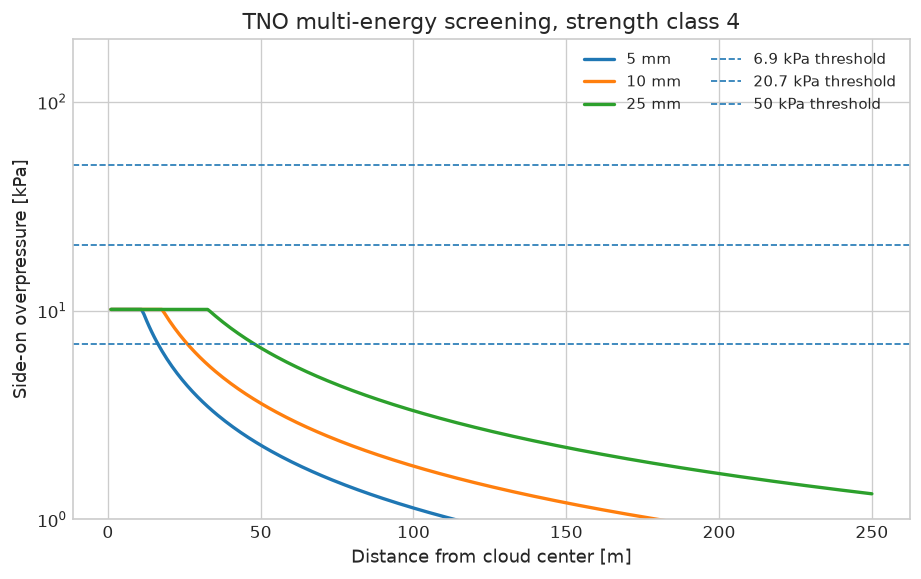

In [15]:
distance_grid_vce_m = np.linspace(1.0, 250.0, 300)
fig, ax = plt.subplots(figsize=(9, 5.2))
for diameter_mm, model in vce_models.items():
    overpressure_kpa = np.array(
        [
            model.overpressurePa(distance) / 1000.0
            for distance in distance_grid_vce_m
        ]
    )
    ax.plot(
        distance_grid_vce_m,
        overpressure_kpa,
        linewidth=2,
        label=f"{diameter_mm:.0f} mm",
    )
for target in overpressure_targets_kpa:
    ax.axhline(
        target,
        linestyle="--",
        linewidth=1,
        label=f"{target:g} kPa threshold",
    )
ax.set(
    xlabel="Distance from cloud center [m]",
    ylabel="Side-on overpressure [kPa]",
    title="TNO multi-energy screening, strength class 4",
    yscale="log",
    ylim=(1, 200),
)
ax.legend(ncol=2)
plt.show()

## Integrated consequence envelope

In [16]:
selected_hole_mm = 25.0
selected_wind_m_s = 5.0
selected_dispersion = dispersion_results[
    (selected_hole_mm, selected_wind_m_s)
]
selected_jet = jet_fire_models[selected_hole_mm]
selected_vce = vce_models[selected_hole_mm]

envelope_rows = [
    {
        "effect": "Toxic gas",
        "criterion": "100 ppm H₂S",
        "distance [m]": selected_dispersion.getToxicDistanceM(),
        "model": selected_dispersion.getSelectedModel(),
    },
    {
        "effect": "Flammable gas",
        "criterion": "0.5 LFL",
        "distance [m]": (
            selected_dispersion.getDistanceToFlammableEndpointM()
        ),
        "model": selected_dispersion.getSelectedModel(),
    },
    {
        "effect": "Jet fire",
        "criterion": "12.5 kW/m²",
        "distance [m]": selected_jet.distanceToFlux(12_500.0),
        "model": "Point source",
    },
    {
        "effect": "VCE",
        "criterion": "6.9 kPa",
        "distance [m]": selected_vce.distanceToOverpressure(6_900.0),
        "model": "TNO class 4",
    },
]
consequence_envelope = pd.DataFrame(envelope_rows)
consequence_envelope["distance [m]"] = (
    consequence_envelope["distance [m]"].astype(float).round(2)
)
display(consequence_envelope)

,effect,criterion,distance [m],model
0,Toxic gas,100 ppm H₂S,84.61,"(G, A, U, S, S, I, A, N, _, P, L, U, M, E)"
1,Flammable gas,0.5 LFL,81.34,"(G, A, U, S, S, I, A, N, _, P, L, U, M, E)"
2,Jet fire,12.5 kW/m²,16.00,Point source
3,VCE,6.9 kPa,48.06,TNO class 4


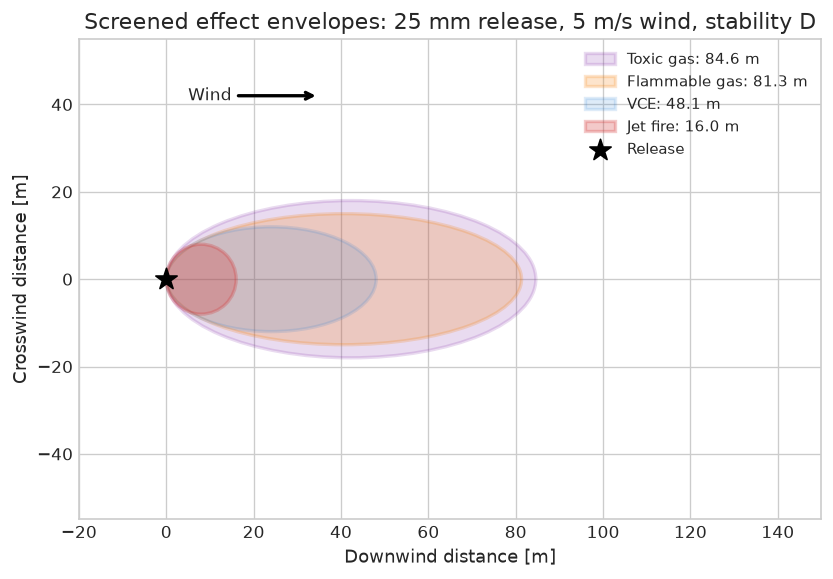

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_aspect("equal")
ax.set_xlim(-20, 150)
ax.set_ylim(-55, 55)

palette = {
    "Toxic gas": ("#7B1FA2", 0.16),
    "Flammable gas": ("#F57C00", 0.20),
    "Jet fire": ("#D32F2F", 0.26),
    "VCE": ("#1976D2", 0.14),
}
widths = {
    "Toxic gas": 36.0,
    "Flammable gas": 30.0,
    "Jet fire": 16.0,
    "VCE": 24.0,
}

for _, row in consequence_envelope.sort_values(
    "distance [m]",
    ascending=False,
).iterrows():
    color, alpha = palette[row["effect"]]
    distance = row["distance [m]"]
    ellipse = patches.Ellipse(
        (distance / 2.0, 0.0),
        width=distance,
        height=widths[row["effect"]],
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=2,
        label=f"{row['effect']}: {distance:.1f} m",
    )
    ax.add_patch(ellipse)

ax.scatter(0, 0, marker="*", s=180, color="black", label="Release")
ax.annotate(
    "Wind",
    xy=(35, 42),
    xytext=(5, 42),
    arrowprops={"arrowstyle": "->", "lw": 2},
    va="center",
)
ax.set(
    xlabel="Downwind distance [m]",
    ylabel="Crosswind distance [m]",
    title=(
        "Screened effect envelopes: 25 mm release, "
        "5 m/s wind, stability D"
    ),
)
ax.legend(loc="upper right")
plt.show()

## Validation and quality gates

In [18]:
release_rates = source_summary["peak release [kg/s]"].to_numpy()
mass_released = source_summary["total released [kg]"].to_numpy()
flammable_by_hole = (
    dispersion_df[dispersion_df["wind [m/s]"] == 5.0]
    .sort_values("hole [mm]")["0.5 LFL distance [m]"]
    .to_numpy()
)
flammable_by_wind = (
    dispersion_df[dispersion_df["hole [mm]"] == 25.0]
    .sort_values("wind [m/s]")["0.5 LFL distance [m]"]
    .to_numpy()
)

validation = pd.DataFrame(
    [
        {
            "check": "Pinned NeqSim release",
            "value": runtime["neqsim"],
            "pass": runtime["neqsim"] == "3.16.0",
        },
        {
            "check": "Composition closes",
            "value": composition["mole fraction"].sum(),
            "pass": abs(composition["mole fraction"].sum() - 1.0) < 1.0e-12,
        },
        {
            "check": "Native and analytical choked rates agree",
            "value": choked_check["relative difference [%]"].abs().max(),
            "pass": (
                choked_check["relative difference [%]"].abs().max()
                < 0.1
            ),
        },
        {
            "check": "Release rate increases with hole diameter",
            "value": bool(np.all(np.diff(release_rates) > 0.0)),
            "pass": bool(np.all(np.diff(release_rates) > 0.0)),
        },
        {
            "check": "Released mass does not exceed initial inventory",
            "value": mass_released.max() / initial_inventory_kg,
            "pass": bool(
                np.all(mass_released <= initial_inventory_kg * 1.001)
            ),
        },
        {
            "check": "0.5 LFL distance increases with hole size",
            "value": bool(np.all(np.diff(flammable_by_hole) > 0.0)),
            "pass": bool(np.all(np.diff(flammable_by_hole) > 0.0)),
        },
        {
            "check": "0.5 LFL distance decreases with wind speed",
            "value": bool(np.all(np.diff(flammable_by_wind) < 0.0)),
            "pass": bool(np.all(np.diff(flammable_by_wind) < 0.0)),
        },
    ]
)
display(validation)
assert validation["pass"].all()
print("All consequence-analysis validation checks passed.")

All consequence-analysis validation checks passed.


,check,value,pass
0,Pinned NeqSim release,3.16.0,True
1,Composition closes,1.0,True
2,Native and analytical choked rates agree,0.00278,True
3,Release rate increases with hole diameter,True,True
4,Released mass does not exceed initial inventory,0.093272,True
5,0.5 LFL distance increases with hole size,True,True
6,0.5 LFL distance decreases with wind speed,True,True


## Interpretation and limitations

- Source terms are real-gas, transient, and inventory-limited, but do not include
  upstream replenishment, pipe friction, crack growth, or detailed two-phase
  non-equilibrium.
- The passive plume model is appropriate only as a screening model. It does not
  represent deck geometry, modules, ventilation, recirculation, or impingement.
- Jet-fire radiation uses a point source; flame geometry and target orientation are
  not resolved.
- VCE results depend strongly on participating mass and strength class. Those are
  explicit assumptions, not NeqSim predictions.
- H₂S endpoints are concentration distances, not individual-risk contours.
- Thresholds shown here must be replaced by the approved project criteria.

## Summary and suggested exercises

The notebook preserves the full calculation chain:

`NeqSim fluid → transient source term → dispersion → fire/explosion → HAZOP evidence`

Suggested exercises:

1. compare North Sea winter and summer boundary conditions;
2. evaluate a liquid-rich flashing release;
3. add isolation time and upstream replenishment;
4. export a source term to OpenFOAM, FLACS, KFX, or PHAST format;
5. couple endpoint distances to a layout and occupancy model.

## References

- [ISO 17776:2016 — major accident hazard management](https://www.iso.org/standard/63062.html)
- [ISO 23251:2019 — pressure-relieving and depressuring systems](https://www.iso.org/standard/75144.html)
- [NeqSim dispersion and consequence documentation](https://equinor.github.io/neqsim/safety/dispersion_and_consequence)
- [NeqSim release model source](https://github.com/equinor/neqsim/tree/master/src/main/java/neqsim/process/safety/release)
- [NeqSim fire model source](https://github.com/equinor/neqsim/tree/master/src/main/java/neqsim/process/safety/fire)